In [8]:
import os
import mne
import glob
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# Suppress MNE and PyTorch warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
def load_data(experiment, task, window_duration, onset, dataset_path):
    """
    Load the preprocessed EEG epochs for Motor Execution (ME) or Motor Imagery (MI) experiments.

    This function reads preprocessed EEG files (in `.fif` format) from the specified dataset directory,
    extracts task-related and rest-related windows, and generates input arrays with corresponding labels.
    It supports both ME and MI experiments with flexible task definitions and window durations.

    Parameters
    ----------
    experiment : str
        Experiment type, either "ME" (motor execution) or "MI" (motor imagery).
    task : str
        Task name. Either "sit_std" or "std_sit".
    window_duration : float
        Length of the EEG time window (in seconds) to extract from each trial.
    onset : float
        Time offset (in seconds) from event onset to define the extraction window.
        For ME, the window ends at `onset`; for MI, the window starts at `onset`.
    dataset_path : str
        Base directory where the processed EEG dataset is stored. Data should be under
        `<dataset_path>/<EXPERIMENT>_processed/*.fif`.

    Returns
    -------
    X : list of ndarray
        List of EEG trial arrays of shape (n_epochs, n_channels, n_times).
        Each element contains concatenated rest and task segments.
    y : list of ndarray
        List of label arrays corresponding to `X`, where 0 = rest and 1 = task.

    Notes
    -----
    - Trials with mismatched or incomplete window lengths are skipped.
    - Rest epochs are matched to task epochs by event indices to maintain alignment.
    """

    tasks = ["sit_std", "std_sit"]
    if experiment.upper() == "ME":
        target_label = f"{experiment.lower()}_{task}"
        another_label = f"{experiment.lower()}_{tasks[1]}" if tasks[0] == task else f"{experiment.lower()}_{tasks[0]}"
        rest_label = "me_r"
    elif experiment.upper() == "MI":
        initial_pos = task.split("_")[0]
        end_pos = task.split("_")[1]
        target_label = f"{experiment.lower()}_{initial_pos}_{end_pos}"
        another_label = f"{experiment.lower()}_{initial_pos}_{initial_pos}"
        rest_label = f"mi_r_{initial_pos}"

    raw_path = os.path.join(dataset_path, experiment.upper()+"_processed", "*.fif")
    raw_files = sorted(glob.glob(raw_path))

    X, y = [], []
    for file in tqdm(raw_files):
        epochs = mne.read_epochs(file, verbose=False)
        sfreq = int(epochs.info["sfreq"])
        event_id = epochs.event_id

        data = epochs.get_data()  # by default in Volts for EEG
        # peak-to-peak per epoch
        ptp_epoch = data.ptp(axis=(1, 2))              # (n_epochs,)
        # 95th percentile cutoff (top 5%)
        cutoff = np.percentile(ptp_epoch, 95)
        # keep epochs at or below cutoff
        keep_mask = ptp_epoch <= cutoff
        # apply selection
        epochs = epochs[keep_mask]                 # boolean indexing to keep

        # epochs.drop_bad(reject=dict(csd=2e6))

        # Get data for each class
        target_data = epochs[target_label].get_data()
        rest_data = epochs[rest_label].get_data()

        # Match rest epochs using indices of target_label/another_label
        indices = np.where(epochs[[target_label, another_label]].events[:, 2] == event_id[target_label])[0]
        rest_data = rest_data[indices[indices < len(rest_data)]]

        onset_timepoint = int(sfreq * onset)
        window_length = int(sfreq * window_duration)

        # Extract appropriate window
        if experiment.upper() == "ME":
            start_idx = max(0, onset_timepoint - window_length)
            rest_segments = rest_data[:, :, start_idx:onset_timepoint]
            target_segments = target_data[:, :, start_idx:onset_timepoint]        
        elif experiment.upper() == "MI":
            rest_segments = rest_data[:, :, onset_timepoint:onset_timepoint + window_length]
            target_segments = target_data[:, :, onset_timepoint:onset_timepoint + window_length]

        # Skip if bad shape
        if rest_segments.shape[-1] != window_length or target_segments.shape[-1] != window_length:
            continue

        # Labels: 0 = rest, 1 = task
        rest_labels = np.zeros(len(rest_segments), dtype=int)
        target_labels = np.ones(len(target_segments), dtype=int)

        X.append(np.concatenate([rest_segments, target_segments]))
        y.append(np.concatenate([rest_labels, target_labels]))

    return X, y, epochs.ch_names

In [10]:
def get_X_toplt(X, y, ch_names, chs=None):
    """
    Aggregate subject-level averaged signals for plotting.

    Parameters
    ----------
    X : list of ndarray
        Each element shape (n_samples, n_channels, n_times).
    y : list of ndarray
        Each element shape (n_samples,), class labels per sample.
    ch_names : list of str
        All channel names.
    chs : list of str, optional
        Subset of channels to select.

    Returns
    -------
    X_toplot : dict
        {label: array(n_subjects_with_label, n_times)}
    n_channels_used : int
        Number of channels averaged over.
    """
    labels = np.unique(np.concatenate(y))
    X_toplot = {l: [] for l in labels}

    # Precompute channel indices
    if chs:
        try:
            indices = [ch_names.index(ch) for ch in chs]
        except ValueError as e:
            raise ValueError(f"Invalid channel in `chs`: {e}")
    else:
        indices = list(range(len(ch_names)))

    n_channels_used = len(indices)

    for X_sub, y_sub in zip(X, y):
        # select only chosen channels
        X_sub = X_sub[:, indices, :]

        # Average across channels → shape (n_samples, n_times)
        X_avg = X_sub.mean(axis=1)

        # For each class, average across samples
        for l in labels:
            mask = (y_sub == l)
            if np.any(mask):
                X_class = X_avg[mask].mean(axis=0)
                X_toplot[l].append(X_class)

    # Convert lists to arrays
    for l in labels:
        if X_toplot[l]:  # non-empty
            X_toplot[l] = np.stack(X_toplot[l], axis=0)
        else:
            X_toplot[l] = np.empty((0, X[0].shape[-1]))

    return X_toplot, n_channels_used

In [11]:
def plot_byclass(
    X_toplot,                 # dict: {label: [n_trials, n_samples]} OR list length n_classes
    colors,                   # list of colors, len >= n_classes
    legend,                   # list of legend labels, len >= n_classes
    title=None,
    ranges=None,              # {'BP': [-0.8, 0.0], 'MMP': [0.0, 1.0]} or {'BP': (-0.8, 0.0, 0.8), ...}
    range_unit='sec',         # 'sec' or 'index' for all entries
    arrow_kwargs=None,        # shared arrow style
    text_kwargs=None,         # shared text style
    range_y_spacing=0.8       # vertical spacing between range labels
):
    # --- helpers ---
    def sec_to_idx(sec, n_samples, win=(-2.0, 2.0)):
        lo, hi = win
        # map sec in [lo, hi] to [0, n_samples-1]
        return int(round((float(sec) - lo) / (hi - lo) * (n_samples - 1)))

    def normalize_interval(start, stop, unit, n_samples):
        if unit == 'sec':
            a = sec_to_idx(start, n_samples)
            b = sec_to_idx(stop,  n_samples)
        elif unit == 'index':
            a = int(start); b = int(stop)
        else:
            raise ValueError("range_unit must be 'index' or 'sec'.")
        return (a, b) if a <= b else (b, a)

    def draw_range(label, start, stop, y, n_samples):
        s, e = normalize_interval(start, stop, range_unit, n_samples)
        mid_x = (s + e) / 2.0
        plt.annotate(text=label, xy=(mid_x, y), xytext=(mid_x, y), **_text)
        plt.annotate('', xy=(s, y), xytext=(e, y), arrowprops=_arrow)

    # --- shared styles ---
    _arrow = dict(arrowstyle='<->', color='black', linewidth=1.5, shrinkA=0, shrinkB=0)
    if arrow_kwargs:
        _arrow.update(arrow_kwargs)

    _text = dict(ha='center', va='bottom', fontsize=16)
    if text_kwargs:
        _text.update(text_kwargs)

    n_classes = len(X_toplot)
    if len(colors) < n_classes:
        raise ValueError("`colors` must have at least as many entries as there are classes.")
    if len(legend) < n_classes:
        raise ValueError("`legend` must have at least as many entries as there are classes.")

    # determine n_samples from the first non-empty class
    n_samples = None
    for key, value in X_toplot.items():
        if value.size > 0:
            n_samples = value.shape[1]
            break
    if n_samples is None:
        raise ValueError("All classes are empty; nothing to plot.")

    # --- figure ---
    fig = plt.figure(figsize=(10, 4), dpi=100)

    # plot mean ± SEM per class
    for i, (key, value) in enumerate(X_toplot.items()):
        label = key  
        signal = value  # (n_trials, n_samples)
        if signal.size == 0:
            continue  # skip empty classes to avoid NaNs
        mean = signal.mean(axis=0)
        se = signal.std(axis=0, ddof=1) / np.sqrt(signal.shape[0]) if signal.shape[0] > 1 else np.zeros_like(mean)
        plt.plot(mean, label=legend[i], color=colors[i], linewidth=1.5)
        plt.fill_between(np.arange(n_samples), mean - se, mean + se, color=colors[i], alpha=0.2)

    # zero-time (onset) line computed from window mapping
    onset_idx = sec_to_idx(0.0, n_samples)  # maps 0 sec to sample index
    plt.axvline(x=onset_idx, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

    # draw ranges (supports 2-tuple or 3-tuple)
    if ranges:
        # auto lay out y positions if not provided
        base_y = -0.2  # start a bit below the plot area (can tweak)
        i = 0
        for label, val in ranges.items():
            if len(val) == 2:
                start, stop = val
                y_pos = base_y - i * range_y_spacing
            elif len(val) == 3:
                start, stop, y_pos = val
            else:
                raise ValueError("Each ranges entry must be (start, stop) or (start, stop, y_pos).")
            draw_range(label, start, stop, y_pos, n_samples)
            i += 1

    if title:
        # printing instead of title is unusual; use plt.title
        plt.title(title, fontsize=16)

    # x-axis ticks map to seconds for a default window [-2, 2]
    plt.xlabel("Time (s)", fontsize=16)
    plt.ylabel("Amplitude (\u00B5V)", fontsize=16)
    plt.xlim(0, n_samples - 1)
    # 9 ticks from -2 to +2 sec
    xt = np.linspace(0, n_samples - 1, 9)
    plt.xticks(xt, labels=np.linspace(-2, 2, 9), fontsize=14)

    plt.legend(loc='lower left', fontsize=16)
    plt.tight_layout()
    plt.show()

    return fig


In [12]:
selected_chs = ['fc1', 'fcz', 'fc2', 'c1', 'cz', 'c2', 'cp1', 'cpz', 'cp2']

  0%|          | 0/22 [00:00<?, ?it/s]

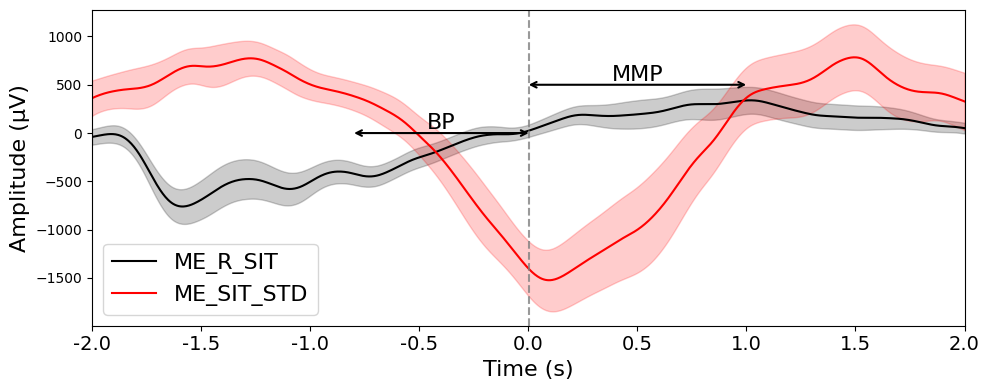

In [13]:
X, y, ch_names = load_data(experiment="ME", task="sit_std", window_duration=4, onset=4, dataset_path="/mount/MI_EEG_database/data")
X_toplot, n_channels = get_X_toplt(X, y, ch_names, selected_chs)
ranges = {'BP': [-0.8, 0.0, 0], 'MMP': [0.0, 1.0, 500]}

fig = plot_byclass(
    X_toplot=X_toplot, 
    colors=['black', 'red'], 
    legend=['ME_R_SIT', 'ME_SIT_STD'], 
    # title=f'Plot {n_channels} channels',
    ranges=ranges, 
    range_unit='sec',
    # arrow_kwargs={'linewidth':2, 'color':'red'},
    # text_kwargs={'fontsize':14, 'fontweight':'bold'}
)

fig.savefig('figure/me_sit_std_slc_chs.pdf', format='pdf')

  0%|          | 0/22 [00:00<?, ?it/s]

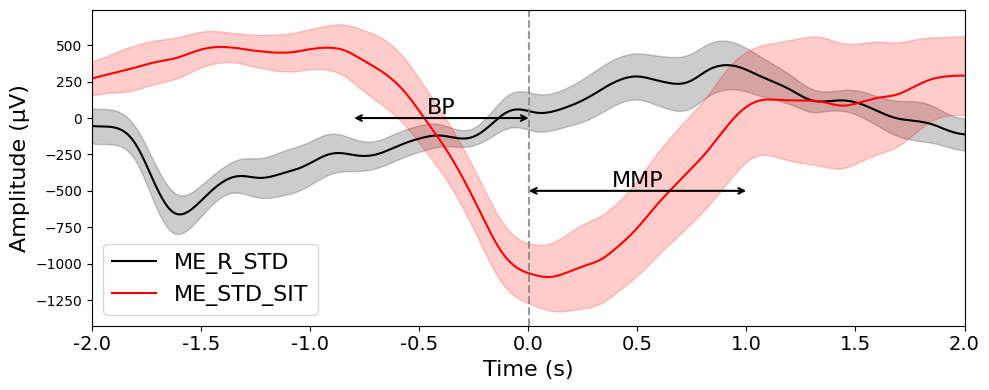

In [14]:
X, y, ch_names = load_data(experiment="ME", task="std_sit", window_duration=4, onset=4, dataset_path="/mount/MI_EEG_database/data")
X_toplot, n_channels = get_X_toplt(X, y, ch_names, selected_chs)
ranges = {'BP': [-0.8, 0.0, 0], 'MMP': [0.0, 1.0, -500]}

fig = plot_byclass(
    X_toplot=X_toplot, 
    colors=['black', 'red'], 
    legend=['ME_R_STD', 'ME_STD_SIT'], 
    # title=f'Plot {n_channels} channels',
    ranges=ranges, 
    range_unit='sec',
    # arrow_kwargs={'linewidth':2, 'color':'red'},
    # text_kwargs={'fontsize':14, 'fontweight':'bold'}
)

fig.savefig('figure/me_std_sit_slc_chs.pdf', format='pdf')